# Final Project Notebook
### Data Science for Healthcare

---
## Project framework

Please read these instructions carefully before starting.

**Your role:** you are a data science team tasked with analysing a real clinical dataset. No explanation of the variables is provided: you will need to explore them, form hypotheses, and find answers.

**The instructor's role:** your instructor acts as the *clinical expert* for this project. You can (and should) consult him whenever you have questions about the clinical meaning of a variable, the plausibility of an analytical choice, or the interpretation of results. Any clinical question you bring will be answered and discussed together.

**No pre-defined path:** this dataset is huge, a lot of different analyses can be performed, so don't search for 'the right one'. Many of them can be right! Just discuss them with the instructor.

**How to document your work:**
At the end of every phase you may add a markdown cell where the team records the choices made and their clinical rationale. This is not a technical comment on the code, it is the trace of your reasoning. **This part is optional**, but it may be useful to you in the final phase of poster composition.

---

## Phase 0: Setup and dataset loading

In [21]:
# Install the library if needed (run once)
!pip install ucimlrepo

In [22]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth', None)

# Load the dataset
support2 = fetch_ucirepo(id=880)

# Features and targets as separate dataframes
X = support2.data.features
y = support2.data.targets

print("Dataset loaded successfully.")
print(f"X (features) shape: {X.shape}")
print(f"y (targets)  shape: {y.shape}")

Dataset loaded successfully.
X (features) shape: (9105, 42)
y (targets)  shape: (9105, 3)


In [23]:
# Dataset metadata
support2.metadata

{'uci_id': 880,
 'name': 'SUPPORT2',
 'repository_url': 'https://archive.ics.uci.edu/dataset/880/support2',
 'data_url': 'https://archive.ics.uci.edu/static/public/880/data.csv',
 'abstract': "This dataset comprises 9105 individual critically ill patients across 5 United States medical centers, accessioned throughout 1989-1991 and 1992-1994.\nEach row concerns hospitalized patient records who met the inclusion and exclusion criteria for nine disease categories: acute respiratory failure, chronic obstructive pulmonary disease, congestive heart failure, liver disease, coma, colon cancer, lung cancer, multiple organ system failure with malignancy, and multiple organ system failure with sepsis. The goal is to determine these patients' 2- and 6-month survival rates based on several physiologic, demographics, and disease severity information. \nIt is an important problem because it addresses the growing national concern over patients' loss of control near the end of life. It enables earlier 

In [24]:
# Variable information: name, role, type
support2.variables

,name,role,type,demographic,description,units,missing_values
0,id,ID,Integer,None,None,None,no
1,age,Feature,Continuous,Age,Age of the patients in years,years,no
2,death,Target,Continuous,None,Death at any time up to National Death Index (NDI) data on 31 of December of 1994. Some patients are discharged before the end of the study and are not followed up. The authors looked up the information about death.,None,no
3,sex,Feature,Categorical,Sex,"Gender of the patient. Listed values are {male, female}.",None,no
4,hospdead,Target,Binary,None,Death in hospital,None,no
5,slos,Other,Continuous,None,Days from Study Entry to Discharge,None,no
6,d.time,Other,Continuous,None,Days of follow-up,None,no
7,dzgroup,Feature,Categorical,None,"The patient's disease sub category amogst ARF/MOSF w/Sepsis, CHF, COPD, Cirrhosis, Colon Cancer, Coma, Lung Cancer, MOSF w/Malig.",None,no
8,dzclass,Feature,Categorical,None,"The patient's disease category amongst ""ARF/MOSF"", ""COPD/CHF/Cirrhosis"", ""Cancer"", ""Coma"".",None,no
9,num.co,Feature,Continuous,None,The number of simultaneous diseases (or comorbidities) exhibited by the patient. Values are ordinal with higher values indicating worse condition and chances of survival.,None,no


In [25]:
df_full = support2.data.original
print("Full dataset:")
print(df_full.head())   

Full dataset:
   id       age  death     sex  hospdead  slos  d.time            dzgroup  \
0   1  62.84998      0    male         0     5    2029        Lung Cancer   
1   2  60.33899      1  female         1     4       4          Cirrhosis   
2   3  52.74698      1  female         0    17      47          Cirrhosis   
3   4  42.38498      1  female         0     3     133        Lung Cancer   
4   5  79.88495      0  female         0    16    2029  ARF/MOSF w/Sepsis   

              dzclass  num.co  ...      crea    sod        ph  glucose  bun  \
0              Cancer       0  ...  1.199951  141.0  7.459961      NaN  NaN   
1  COPD/CHF/Cirrhosis       2  ...  5.500000  132.0  7.250000      NaN  NaN   
2  COPD/CHF/Cirrhosis       2  ...  2.000000  134.0  7.459961      NaN  NaN   
3              Cancer       2  ...  0.799927  139.0       NaN      NaN  NaN   
4            ARF/MOSF       1  ...  0.799927  143.0  7.509766      NaN  NaN   

   urine  adlp adls                sfdm2  adlsc 

---
## Phase 1 — Exploration and Dataset understanding

In [26]:
df_full_copia = support2.data.original.copy()
print("Shape of the dataset:", df_full_copia.shape)
df_full_copia.head() #display first 5 rows

Shape of the dataset: (9105, 48)


,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [27]:
# Quick summary statistics
# .describe() computes count, mean, std, min, 25%, 50%, 75%, max for every numerical column.
# This is one of the first things you should do with any new dataset.
# It helps you spot:
# - Very different scales between features 
# - Potential outliers (look at min/max vs mean)
# - Whether the data makes sense (e.g., no negative values for radius)

df_full_copia.describe()

,id,age,death,hospdead,slos,d.time,num.co,edu,scoma,charges,...,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc
count,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,9105.000000,7471.000000,9104.000000,8.933000e+03,...,6504.000000,9038.000000,9104.000000,6821.000000,4605.000000,4753.000000,4243.000000,3464.000000,6238.000000,9105.000000
mean,4553.000000,62.650823,0.681054,0.259198,17.863042,478.449863,1.868644,11.747691,12.058546,5.999579e+04,...,2.554463,1.770961,137.568541,7.415364,159.873398,32.349463,2191.546047,1.157910,1.637384,1.888272
std,2628.531434,15.593710,0.466094,0.438219,22.006440,560.383272,1.344409,3.447743,24.636694,1.026488e+05,...,5.318448,1.686041,6.029326,0.080563,88.391541,26.792288,1455.245777,1.739672,2.231358,2.003763
min,1.000000,18.041990,0.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,1.169000e+03,...,0.099991,0.099991,110.000000,6.829102,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2277.000000,52.797000,0.000000,0.000000,6.000000,26.000000,1.000000,10.000000,0.000000,9.740000e+03,...,0.500000,0.899902,134.000000,7.379883,103.000000,14.000000,1165.500000,0.000000,0.000000,0.000000
50%,4553.000000,64.856990,1.000000,0.000000,11.000000,233.000000,2.000000,12.000000,0.000000,2.502400e+04,...,0.899902,1.199951,137.000000,7.419922,135.000000,23.000000,1968.000000,0.000000,1.000000,1.000000
75%,6829.000000,73.998960,1.000000,1.000000,20.000000,761.000000,3.000000,14.000000,9.000000,6.459800e+04,...,1.899902,1.899902,141.000000,7.469727,188.000000,42.000000,3000.000000,2.000000,3.000000,3.000000
max,9105.000000,101.847960,1.000000,1.000000,343.000000,2029.000000,9.000000,31.000000,100.000000,1.435423e+06,...,63.000000,21.500000,181.000000,7.769531,1092.000000,300.000000,9000.000000,7.000000,7.000000,7.073242


In [28]:
df_full_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        9105 non-null   int64  
 1   age       9105 non-null   float64
 2   death     9105 non-null   int64  
 3   sex       9105 non-null   object 
 4   hospdead  9105 non-null   int64  
 5   slos      9105 non-null   int64  
 6   d.time    9105 non-null   int64  
 7   dzgroup   9105 non-null   object 
 8   dzclass   9105 non-null   object 
 9   num.co    9105 non-null   int64  
 10  edu       7471 non-null   float64
 11  income    6123 non-null   object 
 12  scoma     9104 non-null   float64
 13  charges   8933 non-null   float64
 14  totcst    8217 non-null   float64
 15  totmcst   5630 non-null   float64
 16  avtisst   9023 non-null   float64
 17  race      9063 non-null   object 
 18  sps       9104 non-null   float64
 19  aps       9104 non-null   float64
 20  surv2m    9104 non-null   floa

In [29]:
# Checking for missing values
# Real clinical data almost always has missing values.
# .isnull().sum() counts how many NaN values each column has.

missing = df_full_copia.isnull().sum()
print("Missing values per column:\n")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Missing values per column:

edu        1634
income     2982
scoma         1
charges     172
totcst      888
totmcst    3475
avtisst      82
race         42
sps           1
aps           1
surv2m        1
surv6m        1
prg2m      1649
prg6m      1633
dnr          30
dnrday       30
meanbp        1
wblc        212
hrt           1
resp          1
temp          1
pafi       2325
alb        3372
bili       2601
crea         67
sod           1
ph         2284
glucose    4500
bun        4352
urine      4862
adlp       5641
adls       2867
sfdm2      1400
dtype: int64


In [ ]:
#CATEGORICAL VALUES
# Classify each attribute

#  Let's see what pandas automatically detects:
print("Data types detected by pandas:\n")
print(df_full_copia.dtypes)

# float64: pandas detected a numerical column 
# object: pandas detected a text/string column (categorical)

# But pandas can't tell the difference between nominal and ordinal!
# That requires domain knowledge (understanding what the data means).

Data types detected by pandas:

id            int64
age         float64
death         int64
sex          object
hospdead      int64
slos          int64
d.time        int64
dzgroup      object
dzclass      object
num.co        int64
edu         float64
income       object
scoma       float64
charges     float64
totcst      float64
totmcst     float64
avtisst     float64
race         object
sps         float64
aps         float64
surv2m      float64
surv6m      float64
hday          int64
diabetes      int64
dementia      int64
ca           object
prg2m       float64
prg6m       float64
dnr          object
dnrday      float64
meanbp      float64
wblc        float64
hrt         float64
resp        float64
temp        float64
pafi        float64
alb         float64
bili        float64
crea        float64
sod         float64
ph          float64
glucose     float64
bun         float64
urine       float64
adlp        float64
adls        float64
sfdm2        object
adlsc       float64
dtype: o

In [39]:
!pip install missingno
import missingno as msno


<Axes: >

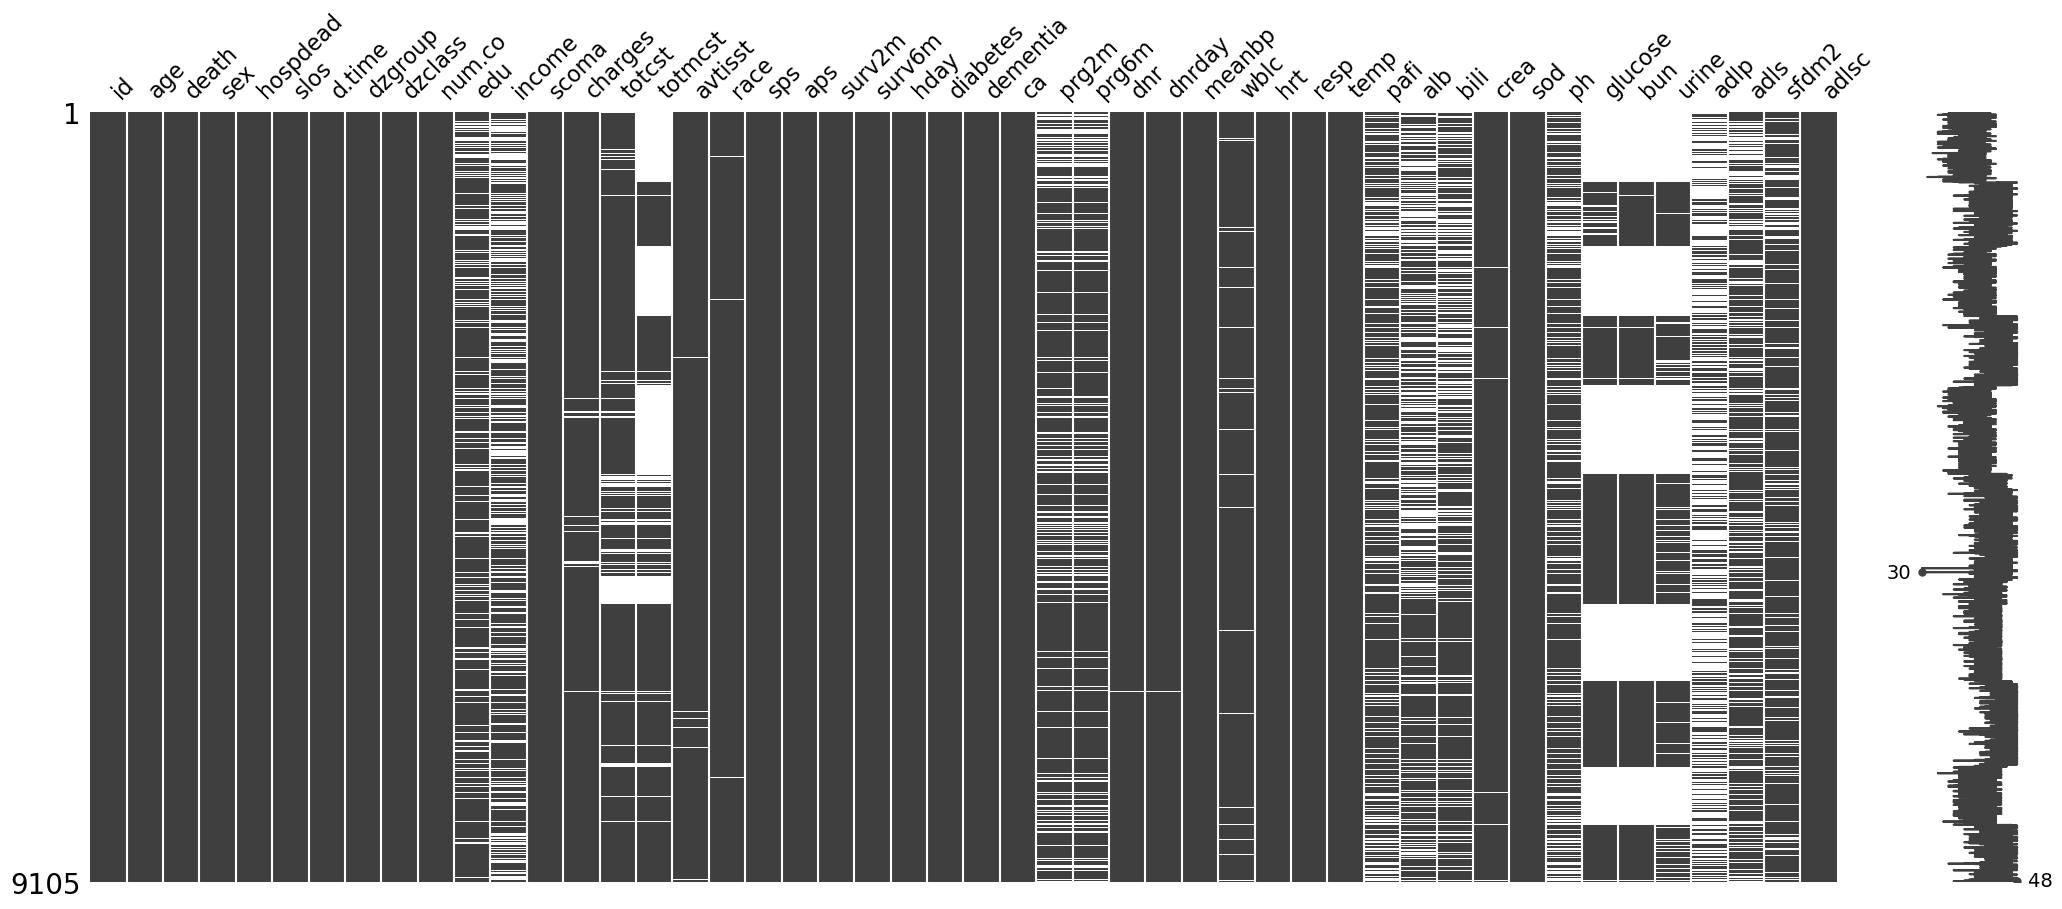

In [38]:
msno.matrix(df_full_copia)

In [ ]:
# Mostra solo le righe dove 'dnr' ha valori mancanti
df_dnr_mancanti=df_full_copia[df_full_copia["dnr"].isna()]
print(df_dnr_mancanti)

        id       age  death     sex  hospdead  slos  d.time  \
1        2  60.33899      1  female         1     4       4   
165    166  52.66800      1  female         1    13      13   
173    174  37.71899      1    male         1     7       7   
187    188  63.85999      1  female         1     5       5   
768    769  47.98099      0  female         0     4    1364   
1015  1016  55.58398      1  female         0   110     208   
1558  1559  68.34198      1    male         1    24      24   
1584  1585  59.31000      0    male         0     5     346   
3093  3094  29.29799      0    male         0    13     492   
3129  3130  75.27399      1    male         1    10      10   
4396  4397  26.04500      0    male         0    31    1029   
4459  4460  67.09094      1    male         0    10     568   
4514  4515  44.32898      1    male         0     5     864   
4537  4538  62.86398      0    male         0     5     957   
5393  5394  62.52197      1    male         1     3    

In [46]:
# Restituisce il numero totale di NaN nella colonna
conteggio = df_full_copia['dnr'].isna().sum()

print(f"Ci sono {conteggio} valori mancanti.")

Ci sono 30 valori mancanti.


In [49]:
percentuale = df_full_copia['dnr'].isna().mean() * 100
print(f"Manca il {percentuale:.2f}% dei dati.")

Manca il 0.33% dei dati.


In [ ]:
# Rimuovo i mancanti nel target dnr??? Capire il perche mancano, cmq sono da togliere
#df = df.dropna(subset=['dnr'])